# Prospect vs. League-Average Performance Index (WIP)

**Goal:** track a set of hitting prospects on plate-discipline, batted-ball, and exit-velo stats,
and see how each one compares to MLB average on each.

**Data:** wide format — one row per stat (`BB%`, `K%`, `BB/K`, `LD%`, `GB%`, `FB%`, `IFFB%`,
`HR/FB%`, `PULL%`, `Z-Swing%`, `O-Swing%`, `Max-EV`, `90-EV`, `Barrel%`), one column per prospect,
plus an `MLB Average` column already included per stat.

> **TODO / open question:** right now every comparison is against the **MLB average**, which
> makes sense for the swing-decision / "process" stats (BB%, K%, Z-Swing%, O-Swing%, etc.) since
> that's the skill I ultimately care about regardless of level. But I still want to add **minor
> league level averages** as a second baseline, especially for anything
> batted-ball or exit-velo related, so I can see "good for their level" vs. "already MLB-ready" as
> two different signals instead of collapsing them into one number.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Load raw data

Raw sheet as exported stat names down the side, players across the top, `MLB Average` as its
own column. (note, this is a bit for my Dad so I have a lot of basic notes included)


In [ ]:
CSV_PATH = "prospects.csv"  # Tracking sheet of current cards you hold. Data is currently manually scrapped as such (excel to CSV for now)

raw = pd.read_csv(CSV_PATH)
raw


,Stat,MLB Average,Wehiwa Aloy,Dante Nori,Andrew Fischer,Daniel Piercre,ROch CHOLOWSKY,Grady Emerson,Josue De Paula
0,BB%,8.30%,10.10%,14.70%,16.90%,7.90%,12.00%,NaN,13.80%
1,K%,22.40%,25.70%,13.00%,33.60%,28.60%,12.00%,NaN,14.80%
2,BB/K,0.37,0.39,0.88,0.5,0.28,1,NaN,0.93
3,LD%,38.30%,23.00%,45.10%,23.10%,28.60%,NaN,NaN,27.80%
4,GB%,42.00%,45.60%,28.90%,21.40%,35.70%,35.70%,NaN,40.50%
5,FB%,19.70%,31.40%,26.00%,55.50%,35.70%,NaN,NaN,31.70%
6,IFFB%,10.10%,16.00%,20.00%,17.80%,33.30%,NaN,NaN,10.90%
7,HR/FB%,11.70%,20.00%,4.40%,32.70%,13.30%,NaN,NaN,20.90%
8,PULL%,40.80%,37.90%,33.30%,57.90%,53.60%,NaN,NaN,44.80%
9,Z-Swing%,68.80%,NaN,24.90%,NaN,NaN,NaN,NaN,NaN


## 2. Clean it up

A few known issues in the raw export, all handled here:

- Column headers have stray whitespace / inconsistent casing due to manually writing (`" Grady Emerson"`, `"ROch CHOLOWSKY"`)
- Percent stats are strings like `"10.10%"` instead of numbers
- At least one bad cell (`Barrel%` / Josue De Paula) has `"---"` instead of a value or a blank. Common for in zone and out of zone% as well, and EV. Several cells are just missing (players with incomplete scouting data so far)


In [ ]:
df = raw.copy()

df.columns = [c.strip() for c in df.columns]

value_cols = [c for c in df.columns if c != "Stat"]

def clean_value(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip()
    if v in ("", "-", "--", "---", "n/a", "N/A"):
        return np.nan
    if v.endswith("%"):
        try:
            return float(v[:-1])
        except ValueError:
            return np.nan
    try:
        return float(v)
    except ValueError:
        return np.nan

for c in value_cols:
    df[c] = df[c].apply(clean_value)

df = df.set_index("Stat")
df


,MLB Average,Wehiwa Aloy,Dante Nori,Andrew Fischer,Daniel Piercre,ROch CHOLOWSKY,Grady Emerson,Josue De Paula
Stat,,,,,,,,
BB%,8.30,10.10,14.70,16.9,7.90,12.0,NaN,13.80
K%,22.40,25.70,13.00,33.6,28.60,12.0,NaN,14.80
BB/K,0.37,0.39,0.88,0.5,0.28,1.0,NaN,0.93
LD%,38.30,23.00,45.10,23.1,28.60,NaN,NaN,27.80
GB%,42.00,45.60,28.90,21.4,35.70,35.7,NaN,40.50
FB%,19.70,31.40,26.00,55.5,35.70,NaN,NaN,31.70
IFFB%,10.10,16.00,20.00,17.8,33.30,NaN,NaN,10.90
HR/FB%,11.70,20.00,4.40,32.7,13.30,NaN,NaN,20.90
PULL%,40.80,37.90,33.30,57.9,53.60,NaN,NaN,44.80


## 3. Data completeness check

Quick look at how much is actually filled in per player before drawing conclusions from anyone's
row.


In [4]:
player_cols = [c for c in df.columns if c != "MLB Average"]
completeness = df[player_cols].notna().sum().sort_values(ascending=False)
completeness.name = "stats_filled_in"
completeness.to_frame().assign(out_of=len(df))


,stats_filled_in,out_of
Dante Nori,13,14
Wehiwa Aloy,11,14
Andrew Fischer,11,14
Josue De Paula,11,14
Daniel Piercre,10,14
ROch CHOLOWSKY,4,14
Grady Emerson,0,14


## 4. Reshape to long format + diff vs. MLB average

One row per (player, stat), with the MLB average and the delta alongside each value. This is the
shape everything downstream (charts, ranking) will use.


In [5]:
long = (
    df[player_cols]
    .reset_index()
    .melt(id_vars="Stat", var_name="player", value_name="value")
)

mlb_avg_lookup = df["MLB Average"]
long["mlb_avg"] = long["Stat"].map(mlb_avg_lookup)
long["vs_mlb"] = (long["value"] - long["mlb_avg"]).round(2)

long.dropna(subset=["value"]).sort_values(["player", "Stat"])


,Stat,player,value,mlb_avg,vs_mlb
40,90-EV,Andrew Fischer,106.00,104.80,1.20
28,BB%,Andrew Fischer,16.90,8.30,8.60
30,BB/K,Andrew Fischer,0.50,0.37,0.13
33,FB%,Andrew Fischer,55.50,19.70,35.80
32,GB%,Andrew Fischer,21.40,42.00,-20.60
35,HR/FB%,Andrew Fischer,32.70,11.70,21.00
34,IFFB%,Andrew Fischer,17.80,10.10,7.70
29,K%,Andrew Fischer,33.60,22.40,11.20
31,LD%,Andrew Fischer,23.10,38.30,-15.20
39,Max-EV,Andrew Fischer,113.00,118.00,-5.00


## 5. Per-player snapshot: plate discipline focus

Starting with just the "process" stats I trust the MLB-average comparison for: `BB%`, `K%`,
`BB/K`, `Z-Swing%`, `O-Swing%`. (Batted-ball / exit-velo stats are still in the data but I'm
holding off scoring those until there's a level-adjusted baseline. See TODO).


In [ ]:
process_stats = ["BB%", "K%", "BB/K", "Z-Swing%", "O-Swing%"]

process = long[long["Stat"].isin(process_stats)].pivot(index="player", columns="Stat", values="vs_mlb")
process = process[process_stats]  # consistent column order
process


Stat,BB%,K%,BB/K,Z-Swing%,O-Swing%
player,,,,,
Andrew Fischer,8.6,11.2,0.13,NaN,NaN
Daniel Piercre,-0.4,6.2,-0.09,NaN,NaN
Dante Nori,6.4,-9.4,0.51,-43.9,37.4
Grady Emerson,NaN,NaN,NaN,NaN,NaN
Josue De Paula,5.5,-7.6,0.56,NaN,NaN
ROch CHOLOWSKY,3.7,-10.4,0.63,NaN,NaN
Wehiwa Aloy,1.8,3.3,0.02,NaN,NaN


## 6. Quick "who's standing out" pass (process stats only)

Very rough composite for now, just BB% and BB/K counted as
better-when-positive, K% counted as better-when-negative. `NaN` stats are excluded from a
player's score rather than zero-filled, so scores aren't directly comparable between players with
very different amounts of missing data (flagged in the completeness table above).


In [7]:
def rough_score(row):
    parts = []
    if pd.notna(row.get("BB%")):
        parts.append(row["BB%"])
    if pd.notna(row.get("BB/K")):
        parts.append(row["BB/K"] * 10)  # scale up, BB/K deltas are tiny vs. % deltas
    if pd.notna(row.get("K%")):
        parts.append(-row["K%"])
    return sum(parts) if parts else np.nan

process_scored = process.copy()
process_scored["rough_score"] = process.apply(rough_score, axis=1)
process_scored.sort_values("rough_score", ascending=False)


Stat,BB%,K%,BB/K,Z-Swing%,O-Swing%,rough_score
player,,,,,,
Dante Nori,6.4,-9.4,0.51,-43.9,37.4,20.9
ROch CHOLOWSKY,3.7,-10.4,0.63,NaN,NaN,20.4
Josue De Paula,5.5,-7.6,0.56,NaN,NaN,18.7
Andrew Fischer,8.6,11.2,0.13,NaN,NaN,-1.3
Wehiwa Aloy,1.8,3.3,0.02,NaN,NaN,-1.3
Daniel Piercre,-0.4,6.2,-0.09,NaN,NaN,-7.5
Grady Emerson,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Visualize: BB% and K% vs. MLB average

Simple diverging bar chart, one bar per player per stat, sorted by rough score.


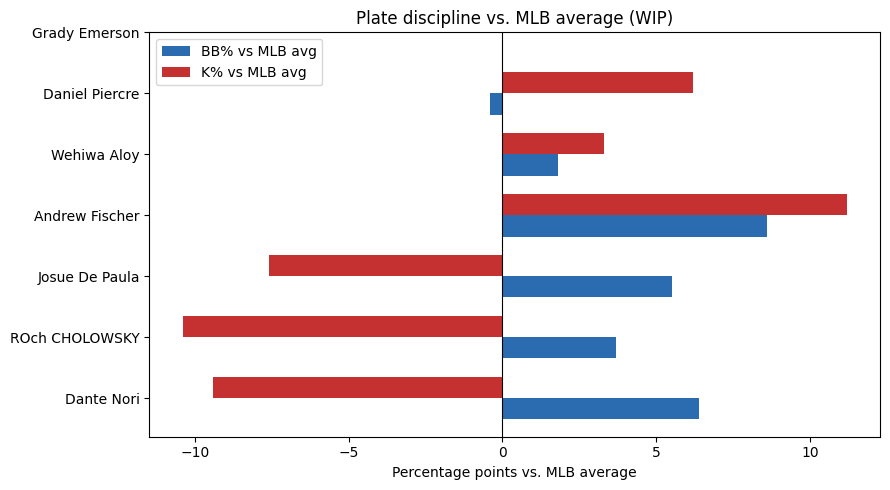

In [8]:
order = process_scored.sort_values("rough_score", ascending=False).index

fig, ax = plt.subplots()
y = np.arange(len(order))
width = 0.35

bb = process_scored.loc[order, "BB%"]
k = process_scored.loc[order, "K%"]

ax.barh(y - width/2, bb, height=width, label="BB% vs MLB avg", color="#2b6cb0")
ax.barh(y + width/2, k, height=width, label="K% vs MLB avg", color="#c53030")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel("Percentage points vs. MLB average")
ax.set_title("Plate discipline vs. MLB average (WIP)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Notes / next steps (WIP log)

- [ ] Add minor-league level averages (A / A+ / AA / AAA) as a second baseline, especially for
      batted-ball and exit-velo stats, so "good for level" and "MLB-ready" don't get collapsed
      into one number
- [ ] Decide how to score batted-ball profile (LD/GB/FB/IFFB/PULL) and exit velo (Max-EV, 90-EV,
      Barrel%) — currently excluded from the rough score since MLB average isn't the right bar yet
- [ ] Source data: Grady Emerson row is almost entirely empty, Josue De Paula's Barrel% is
      `"---"` in the raw sheet — go back to the source and fill in or confirm these are truly
      missing. I probably missed these when we were just picking cards you had for me to go grab stats on.
- [ ] Standardize name formatting at the source (casing, stray leading space) instead of relying
      on the cleanup step here
- [ ] Move from the rough additive score to a real weighted model once I know which stats matter
      most for the "will this guy hit at the next level" question
- [ ] Look into the python baseball library?
